---

_You are currently looking at **version 1.0** of this notebook. To download notebooks and datafiles, as well as get help on Jupyter notebooks in the Coursera platform, visit the [Jupyter Notebook FAQ](https://www.coursera.org/learn/python-machine-learning/resources/bANLa) course resource._

---

## Applied Machine Learning, Module 1:  A simple classification task

### Import required modules and load data file

In [22]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

fruits = pd.read_table('assets/fruit_data_with_colors.txt')

In [17]:
fruits.head()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79


In [18]:
# create a mapping from fruit label value to fruit name to make results easier to interpret
lookup_fruit_name = dict(zip(fruits.fruit_label.unique(), fruits.fruit_name.unique()))   
lookup_fruit_name

{np.int64(1): 'apple',
 np.int64(2): 'mandarin',
 np.int64(3): 'orange',
 np.int64(4): 'lemon'}

The file contains the mass, height, and width of a selection of oranges, lemons and apples. The heights were measured along the core of the fruit. The widths were the widest width perpendicular to the height.

### Examining the data

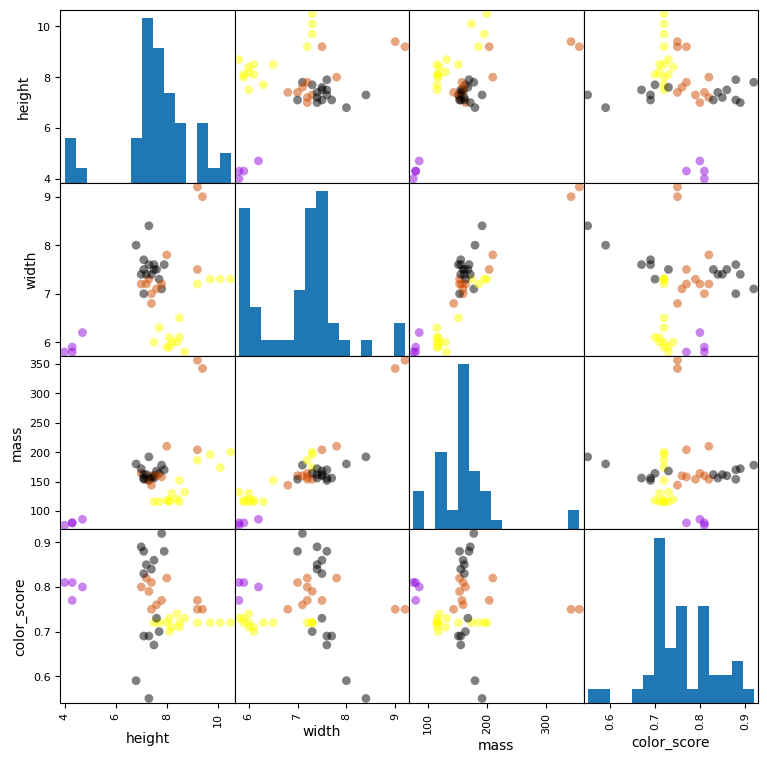

In [25]:
# plotting a scatter matrix
import matplotlib

#This module provides a large set of colormaps, functions for registering new colormaps and for getting a colormap by name, and a mixin class for adding color mapping functionality

X = fruits[['height', 'width', 'mass', 'color_score']] #features
y = fruits['fruit_label']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

cmap = matplotlib.colormaps.get_cmap('gnuplot')
scatter = pd.plotting.scatter_matrix(frame = X_train, c= y_train, marker = 'o', s=40, hist_kwds={'bins':15}, figsize=(9,9), cmap=cmap)

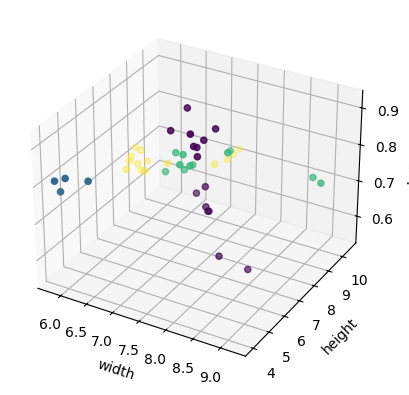

In [26]:
# plotting a 3D scatter plot
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(X_train['width'], X_train['height'], X_train['color_score'], c = y_train, marker = 'o', s=20)
ax.set_xlabel('width')
ax.set_ylabel('height')
ax.set_zlabel('color_score')
plt.show()

### Create train-test split

In [27]:
# For this example, we use the mass, width, and height features of each fruit instance
X = fruits[['mass', 'width', 'height']]
y = fruits['fruit_label']

# default is 75% / 25% train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

### Create classifier object

In [29]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 5)

### Train the classifier (fit the estimator) using the training data

In [30]:
#during fiting the classifier just stores the input data in memory. There is no training that happens
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](4,)","[1,2,3,4]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


### Estimate the accuracy of the classifier on future data, using the test data

In [31]:
knn.score(X_test, y_test)

0.5333333333333333

### Use the trained k-NN classifier model to classify new, previously unseen objects

In [32]:
# first example: a small fruit with mass 20g, width 4.3 cm, height 5.5 cm
fruit_prediction = knn.predict([[20, 4.3, 5.5]])
lookup_fruit_name[fruit_prediction[0]]

c:\Users\singl\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


'mandarin'

In [33]:
# second example: a larger, elongated fruit with mass 100g, width 6.3 cm, height 8.5 cm
fruit_prediction = knn.predict([[100, 6.3, 8.5]])
lookup_fruit_name[fruit_prediction[0]]

c:\Users\singl\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


'lemon'

### Plot the decision boundaries of the k-NN classifier

In [39]:
print(type(X_train)), print(X_train.shape)

<class 'pandas.core.frame.DataFrame'>
(44, 3)


(None, None)

    mass  width  height
42   154    7.2     7.2
48   174    7.3    10.1
7     76    5.8     4.0
14   152    7.6     7.3
32   164    7.2     7.0
49   132    5.8     8.7
29   160    7.0     7.4
37   154    7.3     7.3
56   116    5.9     8.1
18   162    7.5     7.1
55   116    6.3     7.7
27   204    7.5     9.2
15   156    7.7     7.1
5     80    5.8     4.3
31   210    7.8     8.0
16   156    7.6     7.5
50   130    6.0     8.2
20   160    7.5     7.5
51   116    6.0     7.5
8    178    7.1     7.8
13   164    7.3     7.7
25   356    9.2     9.2
17   168    7.5     7.6
58   118    6.1     8.1
57   152    6.5     8.5
52   118    5.9     8.0
38   158    7.2     7.8
1    180    8.0     6.8
12   154    7.0     7.1
45   186    7.2     9.2
24   342    9.0     9.4
6     80    5.9     4.3
23   170    7.6     7.9
36   160    7.1     7.6
21   156    7.4     7.4
19   162    7.4     7.2
9    172    7.4     7.0
39   144    6.8     7.4
54   116    6.1     8.5
3     86    6.2     4.7
0    192    8.4 

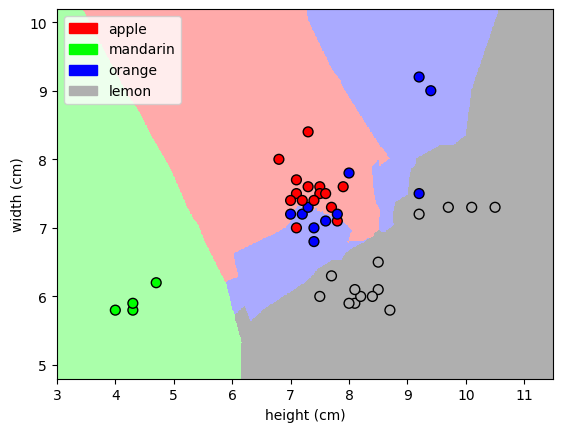

In [36]:
from adspy_shared_utilities import plot_fruit_knn

print(X_train)

plot_fruit_knn(X_train, y_train, 5, 'uniform')   # we choose 5 nearest neighbors

### How sensitive is k-NN classification accuracy to the choice of the 'k' parameter?

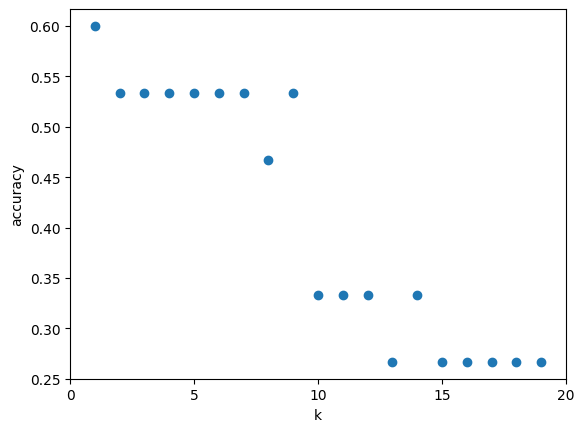

In [ ]:
k_range = range(1,20)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, y_train)
    scores.append(knn.score(X_test, y_test))

plt.figure()
plt.xlabel('k')
plt.ylabel('accuracy')
plt.scatter(k_range, scores)
plt.xticks([0,5,10,15,20]);

 Mandarin class is tiny

The fruit dataset has very few mandarins (~5 total, ~3-4 in training). At low k, a test mandarin finds its true mandarin neighbors and gets classified correctly. As k grows, you pull in more apple/orange points that outvote the 3-4 mandarin training points.

Once k > 2 × (mandarin training count), mandarin can never win a vote even with a mandarin test point sitting right next to mandarin training samples.

Test set is only ~15 samples

Each misclassification = ~6.7% accuracy drop. So losing 1-2 mandarin predictions as k rises shows up as a steep drop.

Not a dataset-size issue — 19/44 = 43% of training, far from a global vote. The drop is specifically about the minority class being voted out by neighbors from larger classes as the neighborhood expands.

### How sensitive is k-NN classification accuracy to the train/test split proportion?

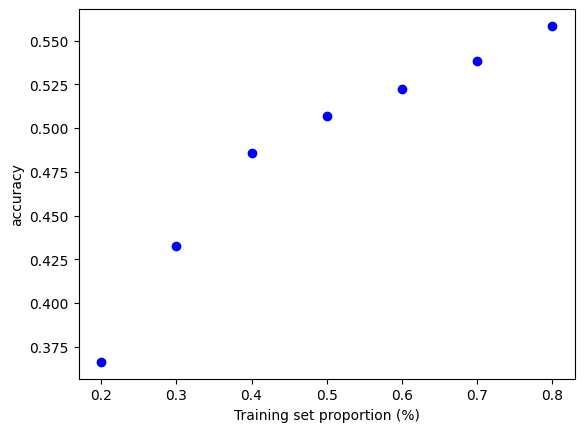

In [41]:
t = [0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2]

knn = KNeighborsClassifier(n_neighbors = 5)

plt.figure()

for s in t:

    scores = []
    for i in range(1,1000):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1-s)
        knn.fit(X_train, y_train)
        scores.append(knn.score(X_test, y_test))
    plt.plot(s, np.mean(scores), 'bo')

plt.xlabel('Training set proportion (%)')
plt.ylabel('accuracy');

"How sensitive is k-NN classification accuracy to the train/test split proportion?"

What the plot shows (accuracy vs training proportion 0.2 → 0.8, k=5, 1000 random splits each):

Accuracy rises as training proportion increases, but not linearly. Typical pattern for this dataset:

Train %	Behavior
0.2 (~12 samples)	Low accuracy, high variance — too few examples to learn 4 classes
0.5 (~30 samples)	Moderate, stabilizing
0.8 (~47 samples)	Best accuracy, but test set is only ~12 samples → noisy estimate
Key insight: This dataset has 59 total samples — small enough that both ends are problematic:

Low train % → model starves, can't learn all 4 classes
High train % → test set too tiny to reliably estimate accuracy (each point = ~8% swing)
Advice: 75/25 (the default train_test_split) is a reasonable middle ground for this dataset. For datasets this small, cross-validation (e.g., cross_val_score with k=5 folds) would give a more reliable accuracy estimate than a single train/test split — it uses all data for both training and evaluation.